In [ ]:
#Question 2: Paper Implementation: Disentangled Representation Learning for Environment-agnostic Speaker Recognition (https://arxiv.org/abs/2406.14559)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd /content/drive/MyDrive/speech/Assignment1

/content/drive/MyDrive/speech/Assignment1


In [ ]:
!pip install torchaudio librosa transformers datasets matplotlib soundfile

In [ ]:
import os
import torch
import torchaudio
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Install the library
!pip install datasets



In [ ]:
# Login to Hugging Face
from huggingface_hub import login
login()  # Enter your token when prompted

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


In [ ]:


# Step 1: Set dataset path
import os
DATA_PATH = "/content/drive/MyDrive/speech/Assignment1/data/librispeech_asr"
os.makedirs(DATA_PATH, exist_ok=True)



In [ ]:
# Step 2: Import datasets
from datasets import load_dataset, load_from_disk

# Step 3: Download or load from disk
if not os.path.exists(DATA_PATH) or len(os.listdir(DATA_PATH)) == 0:
    print("Downloading dataset...")

    dataset = load_dataset(
        "librispeech_asr",
        "clean",
        split="train.100[:200]"   # small subset for assignment
    )

    dataset.save_to_disk(DATA_PATH)
    print("Dataset saved to Drive!")

else:
    print("Dataset already exists. Loading from Drive...")
    dataset = load_from_disk(DATA_PATH)

# Step 4: Check a sample
print(dataset[0])

Dataset already exists. Loading from Drive...
{'file': '/home/albert/.cache/huggingface/datasets/downloads/extracted/bc0d9a6ef85c2d487c9c6efbc91f8892df927c69d3f80545a668cc058d5f677e/374-180298-0000.flac', 'audio': <datasets.features._torchcodec.AudioDecoder object at 0x784969ab0f20>, 'text': 'CHAPTER SIXTEEN I MIGHT HAVE TOLD YOU OF THE BEGINNING OF THIS LIAISON IN A FEW LINES BUT I WANTED YOU TO SEE EVERY STEP BY WHICH WE CAME I TO AGREE TO WHATEVER MARGUERITE WISHED', 'speaker_id': 374, 'chapter_id': 180298, 'id': '374-180298-0000'}


In [ ]:
if isinstance(dataset, dict):
    dataset = dataset["train"]

print(dataset)

Dataset({
    features: ['file', 'text', 'speaker_id', 'chapter_id', 'id', 'features'],
    num_rows: 200
})


In [ ]:
speaker_ids = list(set(dataset["speaker_id"]))
spk2idx = {spk: i for i, spk in enumerate(speaker_ids)}

def encode_labels(example):
    example["label"] = spk2idx[example["speaker_id"]]
    return example

dataset = dataset.map(encode_labels)
num_speakers = len(spk2idx)

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

In [ ]:
import torchaudio

def add_noise(waveform):
    noise = torch.randn_like(waveform) * 0.01
    return waveform + noise

def preprocess(example):
    # 🔥 load audio from file path
    waveform, sr = torchaudio.load(example["file"])

    waveform = waveform.mean(dim=0)  # mono

    # augmentation
    if random.random() > 0.5:
        waveform = add_noise(waveform)

    # Mel spectrogram
    mel = mel_transform(waveform)
    mel = mel.mean(dim=1)

    example["features"] = mel.numpy()
    return example

In [ ]:
dataset = dataset.train_test_split(test_size=0.1)

train_data = dataset["train"]
test_data = dataset["test"]

In [ ]:
def collate_fn(batch):
    xs, ys = zip(*batch)

    # find max length
    max_len = max(x.shape[1] for x in xs)

    padded_xs = []

    for x in xs:
        pad_size = max_len - x.shape[1]
        padded = torch.nn.functional.pad(x, (0, pad_size))  # pad time dim
        padded_xs.append(padded)

    xs = torch.stack(padded_xs)
    ys = torch.tensor(ys)

    return xs, ys

In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset
class SpeechDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        x = torch.tensor(self.dataset[idx]["features"]).float()
        y = torch.tensor(self.dataset[idx]["label"]).long()
        return x, y

train_loader = DataLoader(
    SpeechDataset(train_data),
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    SpeechDataset(test_data),
    batch_size=32,
    collate_fn=collate_fn
)

In [ ]:
class BaselineModel(nn.Module):
    def __init__(self, input_dim=80, hidden_dim=256, num_classes=100):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        # x shape: [batch, 80, T]
        x = x.mean(dim=2)   # 🔥 KEY FIX → [batch, 80]

        return self.net(x)

In [ ]:
class DisentangleModel(nn.Module):
    def __init__(self, input_dim=80, hidden_dim=256, num_speakers=100):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )

        self.z_spk = nn.Linear(hidden_dim, 128)
        self.z_env = nn.Linear(hidden_dim, 128)

        self.classifier = nn.Linear(128, num_speakers)

        self.decoder = nn.Sequential(
            nn.Linear(256, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        # 🔥 FIX HERE
        x = x.mean(dim=2)   # [batch, 80]

        h = self.encoder(x)

        z_spk = self.z_spk(h)
        z_env = self.z_env(h)

        logits = self.classifier(z_spk)

        recon = self.decoder(torch.cat([z_spk, z_env], dim=-1))

        return logits, recon, z_spk

In [ ]:
criterion_cls = nn.CrossEntropyLoss()
criterion_recon = nn.MSELoss()

def disentangle_loss(logits, labels, recon, original):
    original = original.mean(dim=2)   # 🔥 FIX

    loss_cls = criterion_cls(logits, labels)
    loss_recon = criterion_recon(recon, original)

    return loss_cls + 0.5 * loss_recon

In [ ]:
def train(model, loader, optimizer, is_disentangle=False):
    model.train()
    total_loss = 0

    for x, y in loader:
        optimizer.zero_grad()

        if is_disentangle:
            logits, recon, _ = model(x)
            loss = disentangle_loss(logits, y, recon, x)
        else:
            logits = model(x)
            loss = criterion_cls(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            logits = model(x)[0] if isinstance(model, DisentangleModel) else model(x)

            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

In [ ]:
import torch.optim as optim
baseline = BaselineModel(num_classes=num_speakers)
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

for epoch in range(5):
    loss = train(baseline, train_loader, optimizer)
    acc = evaluate(baseline, test_loader)
    print(f"Baseline Epoch {epoch}: Loss={loss:.4f}, Acc={acc:.4f}")

Baseline Epoch 0: Loss=0.6393, Acc=0.9500
Baseline Epoch 1: Loss=0.2074, Acc=1.0000
Baseline Epoch 2: Loss=0.0892, Acc=1.0000
Baseline Epoch 3: Loss=0.0481, Acc=1.0000
Baseline Epoch 4: Loss=0.0307, Acc=1.0000


In [ ]:
model = DisentangleModel(num_speakers=num_speakers)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(5):
    loss = train(model, train_loader, optimizer, is_disentangle=True)
    acc = evaluate(model, test_loader)
    print(f"Disentangled Epoch {epoch}: Loss={loss:.4f}, Acc={acc:.4f}")

Disentangled Epoch 0: Loss=4.7381, Acc=0.9500
Disentangled Epoch 1: Loss=1.9974, Acc=1.0000
Disentangled Epoch 2: Loss=1.1387, Acc=1.0000
Disentangled Epoch 3: Loss=0.9942, Acc=1.0000
Disentangled Epoch 4: Loss=0.7389, Acc=1.0000


In [ ]:
SAVE_PATH = "/content/drive/MyDrive/speech/Assignment1"

In [ ]:
torch.save(baseline.state_dict(), f"{SAVE_PATH}/baseline_model.pth")
torch.save(model.state_dict(), f"{SAVE_PATH}/disentangled_model.pth")

In [ ]:
from sklearn.manifold import TSNE

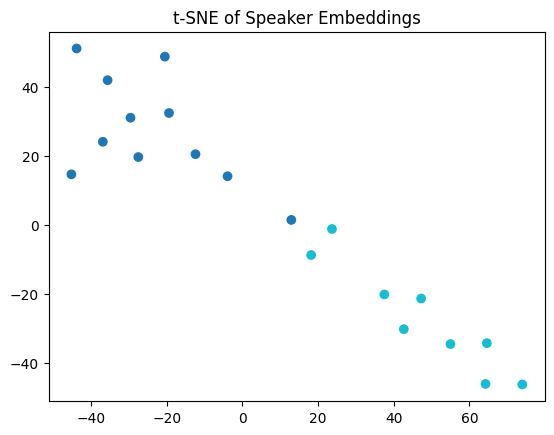

In [ ]:
def extract_embeddings(model, loader):
    model.eval()
    embeddings = []
    labels = []

    with torch.no_grad():
        for x, y in loader:
            if isinstance(model, DisentangleModel):
                _, _, z = model(x)
            else:
                z = model.net[:-1](x)

            embeddings.append(z)
            labels.append(y)

    return torch.cat(embeddings), torch.cat(labels)


emb, lab = extract_embeddings(model, test_loader)

tsne = TSNE(n_components=2, perplexity=5)
emb_2d = tsne.fit_transform(emb.numpy())

plt.scatter(emb_2d[:,0], emb_2d[:,1], c=lab.numpy(), cmap='tab10')
plt.title("t-SNE of Speaker Embeddings")
plt.show()